# Spectral analysis of Photron SA-Z high speed images

This program loads Sanjiv's cavitation nozzle images from Photron SA-Z, and calculates average spectra and spectral heat maps.

    @author Daniel Duke <daniel.duke@monash.edu>
    @copyright (c) 2026 D.Duke
    @license GPL-3.0+
    @version 0.0.1
    @date 23/03/2026
    
    Multiphase Flow Laboratory
    Monash University, Australia


In [1]:
# core functions for image handling and plotting
from pySciCam.pySciCam import ImageSequence # https://github.com/djorlando24/pySciCam

import numpy as np
import os
from tqdm.notebook import tqdm
from scipy.signal import welch
from joblib import Parallel, delayed

import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib widget

## Stage 1. Load images, crop, and remove background.


In [2]:
# Images to load

src_images = '/Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_2__4E4_K_1__01/nz_0__5_3_co2_00_Re_2__4E4_K_1__01.mraw'
#src_images = '/Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_1__5E4_K_1__12/nz_0__5_3_co2_00_Re_1__5E4_K_1__12.mraw'


In [3]:
# Load background
B=ImageSequence(src_images,width=1024,height=1024, rawtype='photron_mraw_mono_16bit',\
               frames=(0,800))

Reading /Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_2__4E4_K_1__01/nz_0__5_3_co2_00_Re_2__4E4_K_1__01.mraw
PFV 16-bit MRAW
File contains 10001 frames (1024 x 1024)
Reading frames 0 to 800
Read 1600.0 MiB in 17.7 sec
	Data in memory:	 (800, 1024, 1024)
	Intensity range:	 0 to 31088 	 uint16
	Array size:	1600.0 MB


In [4]:
# Find number of frames to analyze
nframes = os.path.getsize(src_images)//(B.width*B.height*2)
print("MRAW file has %i frames" % nframes)

MRAW file has 10001 frames


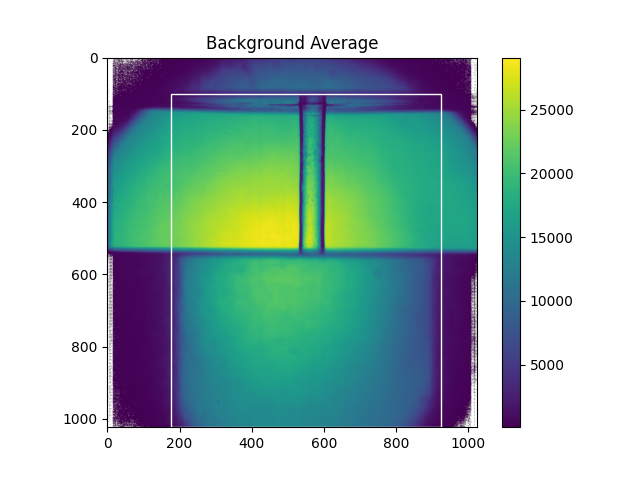

In [5]:
# Background time-averaging
avgBkgnd=np.nanmean(B.arr,axis=0)

# Make a temporary mask to hide dark areas
avgBkgndMasked=avgBkgnd[...]
avgBkgndMasked[avgBkgndMasked<100]=np.nan

# Show background and check cropping
fig=plt.figure()
crop=(100,1024,175,925)
ph=plt.imshow(avgBkgndMasked)

plt.colorbar();
cropBox=mpl.patches.Rectangle((crop[2],crop[0]),crop[3]-crop[2],crop[1]-crop[0],fc='None',ec='w')
fig.gca().add_patch(cropBox);
plt.title("Background Average");

# Apply to avgBkgnd
avgBkgnd=avgBkgnd[crop[0]:crop[1]+1,crop[2]:crop[3]+1]

# Remove original background images to save on memory
del B.arr

In [6]:
# Function to load some images and peform backgorund correction 
def load_chunk_of_images_from_mraw(filename,offset=0,width=1024,height=1024,\
                                   rawtype='photron_mraw_mono_16bit',\
                                   chunk_size=512):
    
    # Load chunk of frames to restrain RAM requirement
    Iset=ImageSequence(filename,width=width,height=height,rawtype=rawtype,\
               frames=(offset,offset+chunk_size))

    # Apply crop same as to bkgnd, from previous 
    Iset.arr = Iset.arr[:,crop[0]:crop[1]+1,crop[2]:crop[3]+1]
    
    # Assign memory to hold new images
    bkRmvSet = np.zeros((Iset.arr.shape[0],Iset.arr.shape[1],Iset.arr.shape[2]),dtype=np.float32)
    sumIntensSet = np.zeros((Iset.arr.shape[0],))
    sumIntensSet2= np.zeros((Iset.arr.shape[0],))
    
    # Background removal of chunk
    for j in range(Iset.N):
        frame = Iset.arr[j,...].astype(np.float32)

        # division method
        #frame[frame<100]=100 # floor on intensity
        #bkRmvSet[j,...] = avgBkgnd / frame

        # subtraction method
        bkRmvSet[j,...] = frame-avgBkgnd

        # save stats
        sumIntensSet[j]=np.nansum(bkRmvSet[j,...])//(Iset.arr.shape[1]*Iset.arr.shape[2])
        sumIntensSet2[j]=np.nansum(bkRmvSet[j,...]**2)//(Iset.arr.shape[1]*Iset.arr.shape[2])
        
    # clear ImageSequence instance
    del Iset
    
    return bkRmvSet, sumIntensSet, sumIntensSet2

In [7]:
# Run loading function in parallel
chunk_size=512
allOutput=Parallel(n_jobs=4, backend='threading', verbose=25)\
    (delayed(load_chunk_of_images_from_mraw)(src_images,i,chunk_size=chunk_size)\
     for i in range(B.N,nframes,chunk_size)) 

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


Reading /Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_2__4E4_K_1__01/nz_0__5_3_co2_00_Re_2__4E4_K_1__01.mrawReading /Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_2__4E4_K_1__01/nz_0__5_3_co2_00_Re_2__4E4_K_1__01.mraw
PFV 16-bit MRAW
File contains 10001 frames (1024 x 1024)
Reading frames 1824 to 2336

PFV 16-bit MRAW
File contains 10001 frames (1024 x 1024)
Reading frames 1312 to 1824
Reading /Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_2__4E4_K_1__01/nz_0__5_3_co2_00_Re_2__4E4_K_1__01.mraw
Reading /Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_2__4E4_K_1__01/nz_0__5_3_co2_00_Re_2__4E4_K_1__01.mraw
PFV 16-bit MRAW
File contains 10001 frames (1024 x 1024)
Reading frames 800 to 1312
PFV 16-bit MRAW
Read 1024.0 MiB in 34.5 sec
	Data in memory:	 (512, 1024, 

[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed:   48.9s
[Parallel(n_jobs=4)]: Done   2 tasks      | elapsed:   49.1s


Reading /Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_2__4E4_K_1__01/nz_0__5_3_co2_00_Re_2__4E4_K_1__01.mraw
PFV 16-bit MRAW
File contains 10001 frames (1024 x 1024)
Reading frames 2848 to 3360
Reading /Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_2__4E4_K_1__01/nz_0__5_3_co2_00_Re_2__4E4_K_1__01.mraw
PFV 16-bit MRAW
File contains 10001 frames (1024 x 1024)
Reading frames 3360 to 3872


[Parallel(n_jobs=4)]: Done   3 tasks      | elapsed:   49.1s


...

[Parallel(n_jobs=4)]: Done  13 out of  18 | elapsed:  3.4min remaining:  1.3min


Read 1024.0 MiB in 12.5 sec
	Data in memory:	 (512, 1024, 1024)
	Intensity range:	 0 to 31216 	 uint16
	Array size:	1024.0 MB
Reading /Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_2__4E4_K_1__01/nz_0__5_3_co2_00_Re_2__4E4_K_1__01.mraw
PFV 16-bit MRAW
File contains 10001 frames (1024 x 1024)
Reading frames 9504 to 10016


[Parallel(n_jobs=4)]: Done  14 out of  18 | elapsed:  3.6min remaining:  1.0min
[Parallel(n_jobs=4)]: Done  15 out of  18 | elapsed:  3.6min remaining:   43.3s
[Parallel(n_jobs=4)]: Done  16 out of  18 | elapsed:  3.6min remaining:   27.1s


Read 994.0 MiB in 12.2 sec
	Data in memory:	 (512, 1024, 1024)
	Intensity range:	 0 to 31120 	 uint16
	Array size:	1024.0 MB


[Parallel(n_jobs=4)]: Done  18 out of  18 | elapsed:  3.8min finished


In [8]:
# Transfer result into a single NumPy array

sumIntens  = np.hstack([ allOutput[n][1] for n in range(len(allOutput)) ], dtype=np.float32)
sumIntens2 = np.hstack([ allOutput[n][2] for n in range(len(allOutput)) ], dtype=np.float32)

bkRmv=np.zeros((len(sumIntens), avgBkgnd.shape[0], avgBkgnd.shape[1]),dtype=np.float32)
chunk_size=allOutput[0][0].shape[0]
for i in range(B.N,nframes,chunk_size):
    print(i,'-',i+chunk_size)
    chunk_size=allOutput[0][0].shape[0]
    bkRmv[i-B.N:i-B.N+allOutput[0][0].shape[0],...]=allOutput[0][0][...]
    allOutput.pop(0)

800 - 1312
1312 - 1824
1824 - 2336
2336 - 2848
2848 - 3360
3360 - 3872
3872 - 4384
4384 - 4896
4896 - 5408
5408 - 5920
5920 - 6432
6432 - 6944
6944 - 7456
7456 - 7968
7968 - 8480
8480 - 8992
8992 - 9504
9504 - 10016


In [9]:
# Remove unneeded variables
del allOutput, B

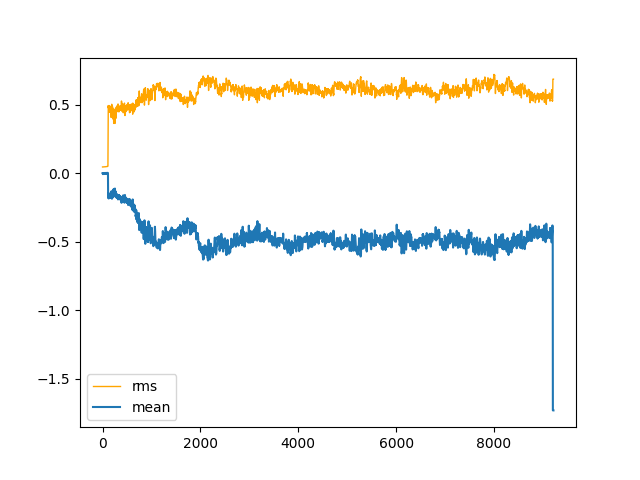

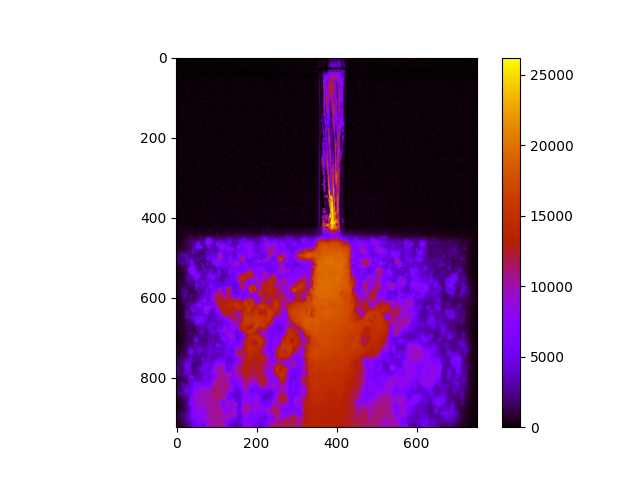

In [18]:
fig=plt.figure()
p1,=plt.plot(np.sqrt(sumIntens2-sumIntens**2)/float(len(sumIntens)+1),label='rms',c='orange',lw=1);
p2,=plt.plot(sumIntens/float(len(sumIntens)),label='mean');
plt.legend([p1,p2],['rms','mean']);
#plt.ylim([0,(np.nanmean(sumIntens)+3*np.nanstd(sumIntens))/float(len(sumIntens))])

fig=plt.figure()
ph=plt.imshow(1-bkRmv[1000,...],cmap='gnuplot',vmin=0);
plt.colorbar(ph);

In [20]:
# Save processed images
output_prefix = os.path.splitext(src_images)[0]
npy_path = output_prefix+'_bkRmv.npz'
np.savez(npy_path, sumIntens=sumIntens, sumIntens2=sumIntens2, bkRmv=bkRmv)
print("Wrote %.0f MB" % (os.path.getsize(npy_path)//1024//1024))

Wrote 24395 MB


In [ ]:
# Save movie
import imageio
bkRmv[bkRmv>4294967295]=4294967294
imageio.mimsave(output_prefix+'_video.mp4', bkRmv.astype(np.uint16))#, fps=30)
print("Wrote %.0f MB" % (os.path.getsize(output_prefix+'_video.mp4')//1024//1024))

## Stage 2. Spectral analysis


In [2]:
# reload modules if starting script here.
import numpy as np
import os
from tqdm.notebook import tqdm
from scipy.signal import welch
from joblib import Parallel, delayed

import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib widget

src_images = '/Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_2__4E4_K_1__01/nz_0__5_3_co2_00_Re_2__4E4_K_1__01.mraw'
#src_images = '/Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_1__5E4_K_1__12/nz_0__5_3_co2_00_Re_1__5E4_K_1__12.mraw'

# Load data back
output_prefix = os.path.splitext(src_images)[0]
npy_path = output_prefix+'_bkRmv.npz'
with np.load(npy_path) as file:
    bkRmv = file['bkRmv']

print("Read %s array from %s" % (bkRmv.shape, os.path.basename(npy_path)))

# Roll axis so time is last
bkRmv = np.rollaxis(bkRmv,2)
bkRmv = np.rollaxis(bkRmv,2)
print(bkRmv.shape)

Read (9216, 924, 751) array from nz_0__5_3_co2_00_Re_2__4E4_K_1__01_bkRmv.npz
(924, 751, 9216)


In [3]:
# Welch Method

nperseg=4096 # output is half this
fs=20000. # fps
t0=300

# Computation of per-pixel spectra
def welch_fun(xx):
    return welch(xx-np.nanmean(xx), fs, nperseg=nperseg,\
                 detrend='constant', return_onesided=True,\
                 scaling='density')
    
def welch_vector(x):
    welch_output = np.zeros((x.shape[0], int(nperseg/2 + 1)))
    for j in range(x.shape[0]):
        f, Pxx = welch_fun(x[j,t0:])
        welch_output[j,:] = Pxx
    return welch_output

# Get freq
f, Pxx = welch_fun(bkRmv[0,0,t0:])

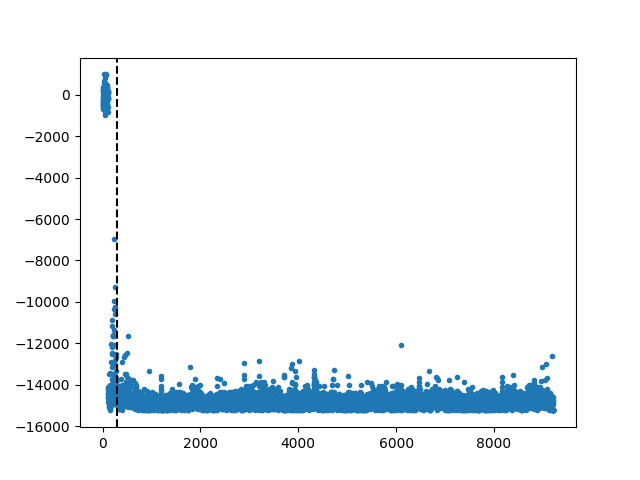

In [4]:
fig=plt.figure()
plt.scatter(np.arange(bkRmv.shape[2]),bkRmv[800,400,:],marker='.');
plt.axvline(300,c='k',ls='--');
#plt.gca().set_yscale('log')

In [5]:
print("n=",bkRmv.shape[0])
all_output = Parallel(n_jobs=8, verbose=10)\
    (delayed(welch_vector)(bkRmv[i,...]) for i in range(bkRmv.shape[0]))

n= 924


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    2.3s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:    3.7s
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    4.9s
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    7.0s
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:   10.5s
[Parallel(n_jobs=8)]: Done  45 tasks      | elapsed:   13.7s
[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed:   17.3s
[Parallel(n_jobs=8)]: Done  69 tasks      | elapsed:   21.8s
[Parallel(n_jobs=8)]: Done  82 tasks      | elapsed:   26.1s
[Parallel(n_jobs=8)]: Done  97 tasks      | elapsed:   31.0s
[Parallel(n_jobs=8)]: Done 112 tasks      | elapsed:   35.5s
[Parallel(n_jobs=8)]: Done 129 tasks      | elapsed:   41.8s
[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:   47.2s
[Parallel(n_jobs=8)]: Done 165 tasks      | elapsed:   54.2s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:  1.0min
[Parallel(

In [6]:
# Convert output of above function into 3d ndarray
#Pxx = np.dstack(all_output)

Pxx=np.zeros((bkRmv.shape[0],bkRmv.shape[1],len(f)),dtype=np.float32)
del bkRmv
for i in range(len(all_output)):
    Pxx[i,...]=all_output[i]

del all_output
#Pxx = np.rollaxis(Pxx,2,0)
print(Pxx.shape)

(924, 751, 2049)


In [9]:
# flow conditions
d=0.5e-3
rhol=997
Re = 2.4e4
K = 1.01
nul=1e-3

# Calculate strouhal number
A = (np.pi/4.)*(d**2)
Ubar = Re*nul/d/rhol
print("Ubar = %f m/s" % Ubar)

Str = f*d/Ubar

Ubar = 48.144433 m/s


In [10]:
# Save processed spectra
output_prefix = os.path.splitext(src_images)[0]
npy_path = output_prefix+'_spectra.npz'
np.savez(npy_path, f=f, Pxx=Pxx, Str=Str)
print("Wrote %.0f MB" % (os.path.getsize(npy_path)//1024//1024))

Wrote 10847 MB


In [11]:
# unconditional mean spectra
meanSpectrum = np.nanmean(Pxx,axis=(0,1))
stdSpectrum = np.nanstd(Pxx,axis=(0,1))

Exception ignored in: <function ResourceTracker.__del__ at 0x1095a18a0>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.12/3.12.13/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/homebrew/Cellar/python@3.12/3.12.13/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/homebrew/Cellar/python@3.12/3.12.13/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1094118a0>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.12/3.12.13/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/homebrew/Cellar/python@3.12/3.12.13/Frameworks/Python.framework/

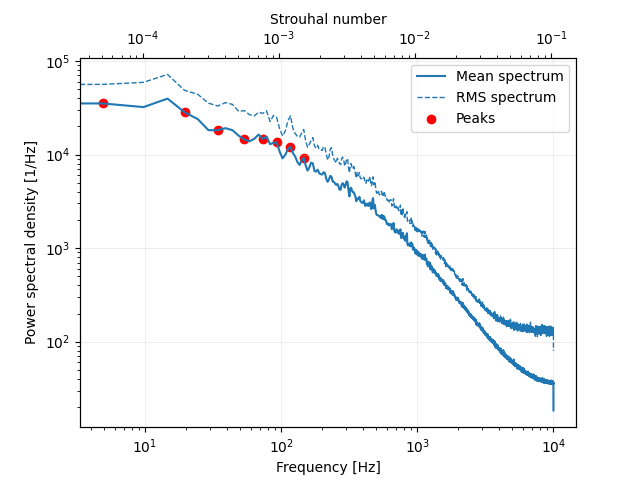

In [18]:
fig=plt.figure()
ax=fig.add_subplot(111)
plt.grid(alpha=.2)
p1,=ax.plot(f, meanSpectrum)
plt.xlabel("Frequency [Hz]");
plt.ylabel("Power spectral density [1/Hz]");
ax2=ax.twiny()
p2,=ax2.plot(Str, stdSpectrum,ls='--',lw=1)
plt.xlabel("Strouhal number");

ax.set_xscale('log'); ax2.set_xscale('log')
ax.set_yscale('log'); ax2.set_yscale('log')

# Find peaks, and remove those that overlap too much
top_indices = np.argpartition(-meanSpectrum, 30)[:30]

bw = 10. # Hz
bw_frac = 0.1
def bracket_freq(fcent):
    fmin=np.round(fcent*(1-bw_frac)-bw,1)
    fmax=np.round(fcent*(1+bw_frac)+bw,1);
    if(fmin<0): fmin=0
    if(fmax>max(f)): fmax=max(f)
    return fmin, fmax


indices=[top_indices[0]]
for i in top_indices[1:]:
    fcent=f[i]
    fmin, fmax = bracket_freq(fcent)
    overlapping = np.any([ (f[j]>fmin) & (f[j]<fmax) for j in indices ])
    if not overlapping: indices.append(i)

p3=ax.scatter(f[indices],meanSpectrum[indices],c='r');
plt.legend([p1,p2,p3],["Mean spectrum","RMS spectrum","Peaks"]);
#plt.savefig(os.path.dirname(src_images)+"/spatial_average_spectrum.pdf");

In [ ]:
for fcent in f[indices]:
    fmin, fmax = bracket_freq(fcent)
        
    fbin = np.where((f>=fmin) & (f<=fmax))[0]

    # Integral of part of spectrum in frequency range
    Pxx_bin = np.zeros((Pxx.shape[0],Pxx.shape[1]))
    for b in fbin:
        Pxx_bin += Pxx[...,b]
    Pxx_bin /= float(len(fbin))

    # Spectrum of pixels where integral is above threshold
    thr = np.nanmean(Pxx_bin) + 2*np.nanstd(Pxx_bin)
    meanSpectrumConditional=np.nanmean(Pxx[Pxx_bin>thr,:],axis=0)
    
    fig=plt.figure()
    ax=fig.add_subplot(121)
    h=ax.imshow(Pxx_bin,cmap='gnuplot',vmin=0,vmax=1000)
    plt.colorbar(h);
    
    ax=fig.add_subplot(122)
    plt.grid(alpha=.2)
    ax.loglog(f, meanSpectrumConditional)
    if len(fbin)<2: fbin = np.hstack(( fbin[0]-1, fbin, fbin[-1]+2 ))
    ax.fill_between(f[fbin],0*meanSpectrumConditional[fbin],meanSpectrumConditional[fbin],alpha=.25)
    plt.xlabel("Freq [Hz]")
    plt.ylabel("Power spectral density [1/Hz]");
    plt.xlim(1,1e3)
    ax2=ax.twiny()
    plt.xlim(1*d/Ubar, 1e3*d/Ubar)
    #ax2.loglog(Str,meanSpectrumConditional)
    plt.xlabel("Strouhal Number")
    
    plt.suptitle("f = %g - %g Hz" % (fmin,fmax))

    plt.tight_layout();
    #plt.savefig(output_dir+"/bracketing_f%fHz.pdf" % fcent);